# 27 â€” P&L Engine

Week 6, Day 3. Computes daily mark-to-market and carry P&L for every portfolio leg, then aggregates to portfolio level.

**Implementation note â€” 1-day execution lag:** The signal on date t is generated at EOD using today's yields. We enter the position at EOD of t; the first P&L is earned from t to t+1. Using same-day yield changes would be a lookahead: the move from tâˆ’1 to t is what *created* the signal, not what we earned. The fix is a one-row shift on the yield-change series.

This notebook walks through:
1. The lookahead problem and the fix (numerically)
2. Leg-level P&L decomposition (MTM vs carry)
3. Portfolio-level equity curve and statistics
4. P&L attribution by maturity and direction

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from termstructure.backtest.pnl import compute_leg_pnl, compute_portfolio_pnl

daily = compute_portfolio_pnl()
leg_pnl = compute_leg_pnl()

print(f'Active P&L dates : {len(daily):,}')
print(f'Total P&L        : ${daily["total_pnl"].sum():>12,.0f}')
print(f'Of which MTM     : ${daily["mtm_pnl"].sum():>12,.0f}')
print(f'Of which Carry   : ${daily["carry_pnl"].sum():>12,.0f}')

Saved 1,662 daily P&L rows -> C:\Users\aarna\Documents\termstructure\data\processed\portfolio_pnl.parquet
Active P&L dates : 1,662
Total P&L        : $   1,009,244
Of which MTM     : $   1,034,169
Of which Carry   : $     -24,925


## 1. The lookahead problem

The rate move on day t that pushes a bond to z > 2 (cheap) is a move AGAINST our intended long position. If we mistakenly compute P&L using that same day's yield change, we capture the divergence rather than the convergence.

The table below shows the P&L sign with and without the shift for a specific signal that was active for multiple consecutive days. The key check: a continuing position (active on both tâˆ’1 and t) earns the move from tâˆ’1 to t, which should be computed correctly either way. An *entry day* (first day of signal) is where the lookahead error shows up.

In [9]:
# Find a streak with actual P&L (cross-reference with leg_pnl to ensure zero_panel coverage).
sig = pd.read_parquet('../data/processed/signal_panel.parquet')
sig['date'] = pd.to_datetime(sig['date'])

# Dates where we have real P&L (not NaN from zero_panel gaps)
valid_dates = set(leg_pnl[leg_pnl['dy_bps'].notna()]['date'])

for mat in [3, 7]:
    sub = (sig[
        (sig['maturity'] == mat) &
        (sig['direction'] != 0) &
        (sig['date'].isin(valid_dates))
    ].sort_values('date').reset_index(drop=True))
    gaps = (sub['date'].diff().dt.days > 5).cumsum()
    streak_counts = sub.groupby(gaps).size()
    long_streak_id = streak_counts[streak_counts >= 5].index[0] if (streak_counts >= 5).any() else None
    if long_streak_id is not None:
        streak = sub[gaps == long_streak_id]
        streak_dates = streak['date'].values[:6]
        streak_dir = int(streak['direction'].iloc[0])
        print(f'{mat}Y, direction={streak_dir:+d}: streak found ({len(streak)} days from {pd.Timestamp(streak_dates[0]).date()})')
        break

# Show signal-leg P&L for that streak
streak_legs = leg_pnl[
    (leg_pnl['date'].isin(streak_dates)) &
    (leg_pnl['signal_maturity'] == mat) &
    (leg_pnl['leg_type'] == 'signal')
][['date','signal_maturity','direction','z_score','dy_bps','mtm_pnl','carry_pnl','total_pnl']]
print()
print(f'Signal leg P&L for {mat}Y streak (1-day lag: position on t earns Dy from t to t+1):')
print(streak_legs.to_string(index=False, float_format=lambda x: f'{x:.2f}'))

3Y, direction=+1: streak found (9 days from 1986-12-04)

Signal leg P&L for 3Y streak (1-day lag: position on t earns Dy from t to t+1):
      date  signal_maturity  direction  z_score  dy_bps   mtm_pnl  carry_pnl  total_pnl
1986-12-04                3          1     2.19    6.76 -67600.00     115.89  -67484.11
1986-12-05                3          1     2.72   -1.34  13400.00     388.36   13788.36
1986-12-08                3          1     2.32   -1.47  14700.00     293.24   14993.24
1986-12-10                3          1     2.09    3.99 -39900.00     430.84  -39469.16
1986-12-11                3          1     2.11    2.89 -28900.00     471.73  -28428.27
1986-12-12                3          1     2.19    2.27 -22700.00     430.11  -22269.89


## 2. Leg-level P&L decomposition

For each position, the four legs (signal + 3 hedges) should sum to a number driven by the residual movement, not the systematic factor movement. The hedges cancel the factor component.

In [10]:
# Pick a date with positions at both maturities and positive total P&L
good_dates = daily[(daily['total_pnl'] > 5000) & (daily['n_signal_legs'] == 2)]['date']
demo_date = good_dates.iloc[0]

demo_legs = leg_pnl[leg_pnl['date'] == demo_date][
    ['signal_maturity','leg_maturity','leg_type','direction','notional','dy_bps','mtm_pnl','carry_pnl','total_pnl']
]
print(f'Leg decomposition for {demo_date.date()}:')
print(demo_legs.round(2).to_string(index=False))
print()
print(f'Portfolio total: ${demo_legs["total_pnl"].sum():,.0f}')

Leg decomposition for 1986-02-21:
 signal_maturity  leg_maturity leg_type  direction     notional  dy_bps    mtm_pnl  carry_pnl  total_pnl
               3           3.0   signal          1  38180074.35   -5.88   58800.00     277.20   59077.20
               3           2.0    hedge          1  -2139252.10   -5.29   -2057.00      -5.40   -2062.40
               3           5.0    hedge          1 -39095664.38   -7.18 -113082.71    -523.13 -113605.84
               3          10.0    hedge          1  10435120.65  -11.87   81703.83     255.99   81959.82
               7           7.0   signal         -1 -19210251.76   -8.90  -89000.00    -347.21  -89347.21
               7           2.0    hedge         -1   4813492.30   -5.29    4628.43      12.15    4640.57
               7           5.0    hedge         -1   7868806.49   -7.18   22760.22     105.29   22865.51
               7          10.0    hedge         -1   9509843.72  -11.87   74459.19     233.29   74692.48

Portfolio total: $38

## 3. Portfolio equity curve

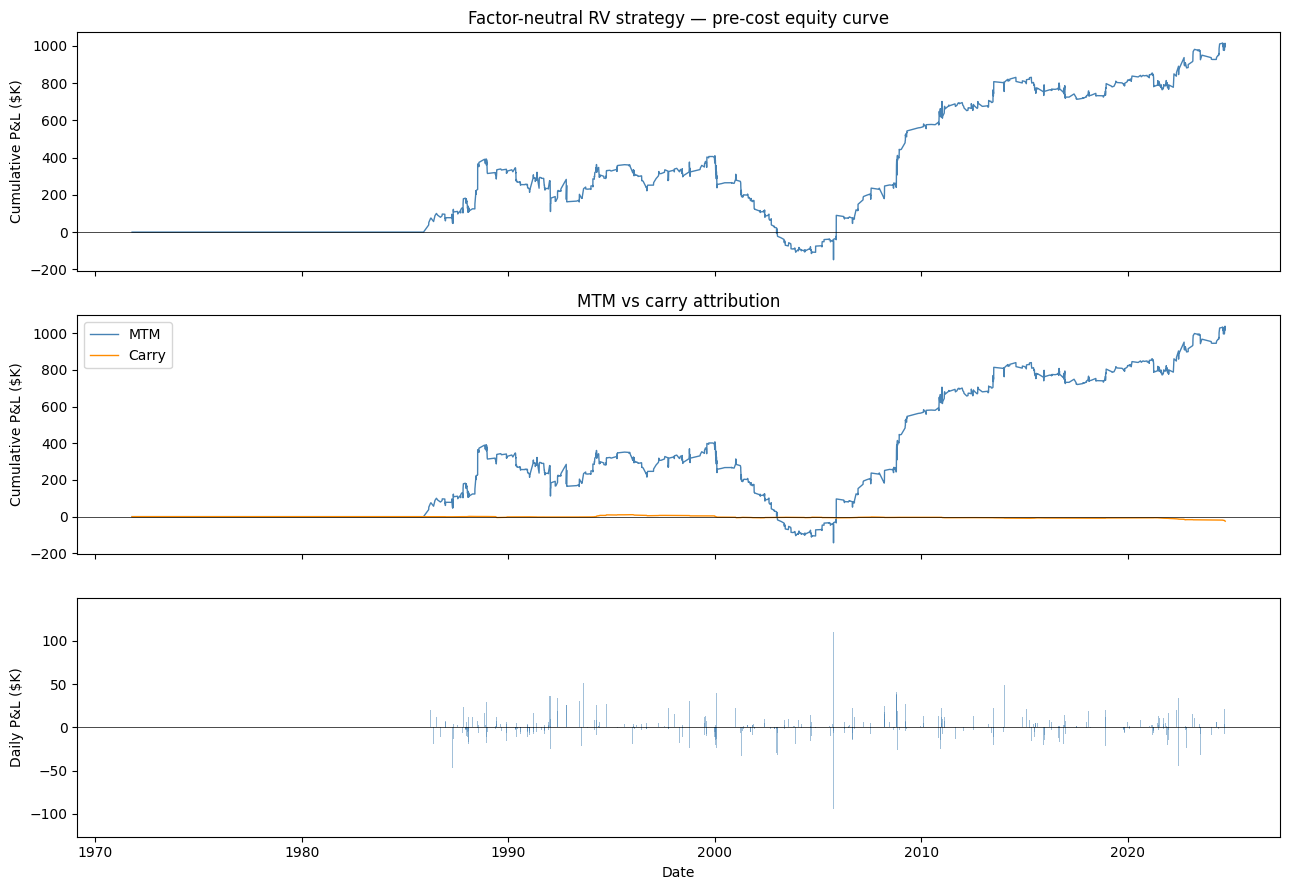

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

# Top: cumulative P&L
ax = axes[0]
ax.plot(daily['date'], daily['cumulative_pnl'] / 1e3, color='steelblue', linewidth=1)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Cumulative P&L ($K)')
ax.set_title('Factor-neutral RV strategy â€” pre-cost equity curve')

# Middle: MTM vs carry decomposition
ax = axes[1]
cum_mtm   = daily['mtm_pnl'].cumsum() / 1e3
cum_carry = daily['carry_pnl'].cumsum() / 1e3
ax.plot(daily['date'], cum_mtm,   label='MTM',   color='steelblue',  linewidth=1)
ax.plot(daily['date'], cum_carry, label='Carry', color='darkorange', linewidth=1)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Cumulative P&L ($K)')
ax.set_title('MTM vs carry attribution')
ax.legend()

# Bottom: daily P&L distribution
ax = axes[2]
ax.bar(daily['date'], daily['total_pnl'] / 1e3, width=5, color='steelblue', alpha=0.5)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Daily P&L ($K)')
ax.set_xlabel('Date')

plt.tight_layout()
plt.show()

In [ ]:
from termstructure.backtest.pnl import compute_transaction_costs, expand_to_full_calendar
from termstructure.report.tearsheet import (
    compute_stats, DEFAULT_COST_BPS, DEFAULT_POS_SCALE,
)

daily["date"] = pd.to_datetime(daily["date"])
positions = pd.read_parquet("../data/processed/portfolio_positions.parquet")
positions["date"] = pd.to_datetime(positions["date"])
n_years = (daily["date"].max() - daily["date"].min()).days / 365.25

tc = compute_transaction_costs(positions, cost_bps=DEFAULT_COST_BPS, position_scale=DEFAULT_POS_SCALE)
merged = daily[["date", "total_pnl"]].merge(
    tc.rename(columns={"transaction_cost": "_tc"}), on="date", how="left"
).fillna(0)
merged["scaled_pnl"] = merged["total_pnl"] * DEFAULT_POS_SCALE
merged["net_pnl"]    = merged["scaled_pnl"] - merged["_tc"]
merged = expand_to_full_calendar(merged)

roll_max = daily["cumulative_pnl"].cummax()
max_dd   = (daily["cumulative_pnl"] - roll_max).min()
active   = daily[daily["total_pnl"] != 0]   # hit_rate only; not used for Sharpe

s_gross = compute_stats(merged.set_index("date")["total_pnl"], n_years=n_years)
s_net   = compute_stats(merged.set_index("date")["net_pnl"],   n_years=n_years)

print("Portfolio statistics (full trading-day calendar, including flat days):")
print(f"  Total P&L (gross)  : ${s_gross['total_pnl']:>12,.0f}")
print(f"  Gross Sharpe       : {s_gross['sharpe']:>12.3f}")
print(f"  Net Sharpe         : {s_net['sharpe']:>12.3f}")
print(f"  Max drawdown       : ${max_dd:>12,.0f}")
print(f"  Hit rate (active)  : {(active['total_pnl'] > 0).mean():>12.1%}")
print(f"  Active days        : {len(active):>12,} of {len(merged):,} trading days")
print()
print("Sharpe denominator = all zero_panel trading days (including ~87% flat/no-position days).")
print("Matches notebook 29 tearsheet methodology.")

## 4. Attribution by maturity and direction

In [13]:
sig_legs = leg_pnl[leg_pnl['leg_type'] == 'signal'].copy()

attr = (
    sig_legs
    .groupby(['signal_maturity', 'direction'])
    .agg(
        n_days=('total_pnl', 'count'),
        total_pnl=('total_pnl', 'sum'),
        mean_pnl=('total_pnl', 'mean'),
        hit_rate=('total_pnl', lambda x: (x > 0).mean()),
    )
)
attr.index = attr.index.set_names(['maturity', 'direction'])
attr['total_pnl'] = attr['total_pnl'].map('${:,.0f}'.format)
attr['mean_pnl']  = attr['mean_pnl'].map('${:,.0f}'.format)
attr['hit_rate']  = attr['hit_rate'].map('{:.1%}'.format)

print('Signal-leg P&L by maturity and direction:')
print(attr.to_string())

Signal-leg P&L by maturity and direction:
                    n_days   total_pnl mean_pnl hit_rate
maturity direction                                      
3        -1            498    $668,913   $1,343    40.1%
          1            481  $1,003,506   $2,086    43.0%
7        -1            461    $676,133   $1,467    37.7%
          1            506    $-78,870    $-156    40.5%


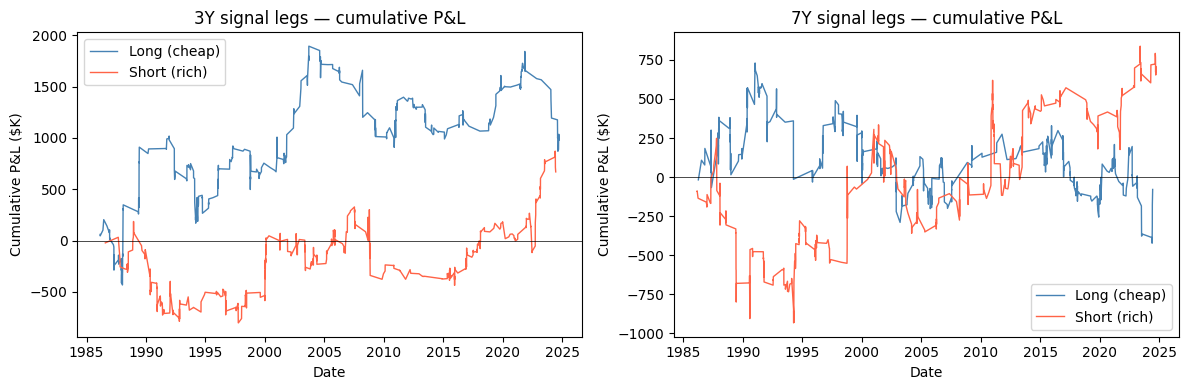

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, mat in zip(axes, [3, 7]):
    sub = sig_legs[sig_legs['signal_maturity'] == mat]
    for direction, label, color in [(1, 'Long (cheap)', 'steelblue'), (-1, 'Short (rich)', 'tomato')]:
        s = sub[sub['direction'] == direction].set_index('date')['total_pnl'].cumsum() / 1e3
        ax.plot(s.index, s.values, label=label, color=color, linewidth=1)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(f'{mat}Y signal legs â€” cumulative P&L')
    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative P&L ($K)')
    ax.legend()

plt.tight_layout()
plt.show()

## Data note: 1970s zero P&L

Positions in 1971â€“1979 show zero P&L because the zero-panel drops dates where *any* maturity in the DEFAULT_MATURITIES list is missing. The early Fed dataset does not have a complete 3Y or 7Y yield series, so those dates are excluded from the zero-panel and yield changes cannot be computed. The signals themselves are valid (z-scores are generated from the sveny columns directly), but they cannot be marked to market.